In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
INPUT_STATS_BASE = "response_cossim_stats"

In [3]:
sns.set(style="whitegrid")
%matplotlib inline

In [4]:
def run_notebook_visualizer():
    # 1. Find all stats files recursively
    stats_files = []
    if not os.path.exists(INPUT_STATS_BASE):
        print(f"Error: Base directory '{INPUT_STATS_BASE}' not found.")
        return

    for root, dirs, files in os.walk(INPUT_STATS_BASE):
        for file in files:
            if file.endswith("_stats.csv"):
                stats_files.append(os.path.join(root, file))

    if not stats_files:
        print(f"No stats files found in {INPUT_STATS_BASE}")
        return

    # 2. Group files by model_quant (provider/model_quant)
    model_groups = {}
    for f in stats_files:
        # Path: INPUT_STATS_BASE/provider/model_quant/category_stats.csv
        parts = f.split(os.sep)
        model_name = parts[-2]
        if model_name not in model_groups:
            model_groups[model_name] = []
        model_groups[model_name].append(f)

    # 3. Iterate and Display
    for model_name, files in model_groups.items():
        print("="*80)
        print(f" MODEL: {model_name} ".center(80, "#"))
        print("="*80)
        
        category_means = {}

        for file_path in files:
            df = pd.read_csv(file_path)
            # Detect category from filename
            category = os.path.basename(file_path).replace("_response_cossim_stats.csv", "")
            # Detect drift column (usually first column)
            drift_col = df.columns[0]
            drift_levels = df[drift_col]

            # --- PLOT 1: Grouped Bar Chart (Per Prompt Similarity) ---
            mean_cols = [c for c in df.columns if c.endswith("_mean") and "overall" not in c]
            prompt_names = [c.replace("_mean", "") for c in mean_cols]
            
            data_matrix = np.array([df[col].values for col in mean_cols])
            y_pos = np.arange(len(prompt_names))
            bar_height = 0.15

            plt.figure(figsize=(12, 6))
            for i in range(len(drift_levels)):
                plt.barh(y_pos + i * bar_height, data_matrix[:, i], 
                         height=bar_height, label=f"Drift {int(drift_levels[i])}")

            plt.yticks(y_pos + bar_height * 2, prompt_names)
            plt.title(f"{model_name} | {category.upper()}\nSimilarity per Prompt Group")
            plt.xlabel("Cosine Similarity (%)")
            plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Drift")
            plt.gca().invert_yaxis()
            plt.tight_layout()
            plt.show() # Render below cell

            # --- PLOT 2: General Category Trends (Mean, Std, Drop) ---
            fig, axes = plt.subplots(1, 3, figsize=(18, 5))
            
            # Subplot 1: Overall Mean
            axes[0].plot(drift_levels, df["overall_mean"], marker="o", color="blue", linewidth=2)
            axes[0].set_title(f"Overall Mean Similarity")
            axes[0].set_xlabel("Drift Level")
            axes[0].set_ylabel("Similarity Score")

            # Subplot 2: Variance (Std)
            axes[1].bar(drift_levels, df["overall_std"], color="lightgray")
            axes[1].set_title(f"Response Variance (Std)")
            axes[1].set_xlabel("Drift Level")

            # Subplot 3: Relative Drop %
            axes[2].plot(drift_levels, df["relative_drop_%"], marker="s", color="red")
            axes[2].set_title(f"Performance Decay (%)")
            axes[2].set_xlabel("Drift Level")

            plt.suptitle(f"General Trends for {category.upper()}", fontsize=16)
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show() # Render below cell

            # Store data for the final model-wide heatmap
            category_means[category] = df["overall_mean"].values

        # --- PLOT 3: Model Summary Heatmap ---
        if category_means:
            print(f"\n--- Summary Heatmap for {model_name} ---")
            heatmap_df = pd.DataFrame(category_means, index=[1, 2, 3, 4, 5])
            plt.figure(figsize=(10, 6))
            sns.heatmap(heatmap_df.T, annot=True, cmap="YlGnBu", fmt=".2f", cbar_kws={'label': 'Similarity %'})
            plt.title(f"{model_name}: Performance Heatmap")
            plt.xlabel("Drift Level")
            plt.ylabel("Category")
            plt.show() # Render below cell
            print("\n" + "_"*80 + "\n")

In [5]:
# run_notebook_visualizer()

In [6]:
def show_model_stats(provider, model_name, bit):
    """
    Displays visualizations for a specific model configuration.
    Example: show_model_stats("mistralai", "Mistral-7B-Instruct-v0.2", "fp16")
    """
    # Construct the target directory path based on your folder structure
    # Structure: ROOT / provider / model_name_bit / 
    target_folder_name = f"{model_name}_{bit}"
    target_path = os.path.join(INPUT_STATS_BASE, provider, target_folder_name)
    
    if not os.path.exists(target_path):
        print(f"Error: Path not found -> {target_path}")
        print("Check if the provider, model name, or bit type matches your folder names exactly.")
        return

    # Find all category stats files in the target folder
    stats_files = [f for f in os.listdir(target_path) if f.endswith("_stats.csv")]
    
    if not stats_files:
        print(f"No statistics files found in {target_path}")
        return

    print("="*80)
    print(f" VISUALIZING: {model_name} ({bit}) ".center(80, "#"))
    print("="*80)

    category_means = {}

    for file in stats_files:
        file_path = os.path.join(target_path, file)
        df = pd.read_csv(file_path)
        
        # Determine category and drift levels
        category = file.replace("_response_cossim_stats.csv", "").upper()
        drift_col = df.columns[0]
        drift_levels = df[drift_col]

        # ---------------------------------------------------------
        # 1. Detailed Prompt Similarity Bar Chart
        # ---------------------------------------------------------
        mean_cols = [c for c in df.columns if c.endswith("_mean") and "overall" not in c]
        prompt_names = [c.replace("_mean", "") for c in mean_cols]
        data_matrix = np.array([df[col].values for col in mean_cols])
        
        y_pos = np.arange(len(prompt_names))
        bar_height = 0.15

        plt.figure(figsize=(12, 6))
        for i in range(len(drift_levels)):
            plt.barh(y_pos + i * bar_height, data_matrix[:, i], 
                     height=bar_height, label=f"Drift {int(drift_levels[i])}")

        plt.yticks(y_pos + bar_height * 2, prompt_names)
        plt.title(f"{category} - Per Prompt Similarity")
        plt.xlabel("Cosine Similarity (%)")
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Drift Level")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

        # ---------------------------------------------------------
        # 2. Category Trend Summary (Mean, Std, Decay)
        # ---------------------------------------------------------
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Overall Mean
        axes[0].plot(drift_levels, df["overall_mean"], marker="o", color="royalblue", linewidth=2)
        axes[0].set_title("Overall Mean Similarity")
        axes[0].set_xlabel("Drift Level")
        axes[0].set_ylabel("Score")

        # Response Variance
        axes[1].bar(drift_levels, df["overall_std"], color="lightgray")
        axes[1].set_title("Response Variance (Std)")
        axes[1].set_xlabel("Drift Level")

        # Performance Decay
        axes[2].plot(drift_levels, df["relative_drop_%"], marker="s", color="crimson")
        axes[2].set_title("Performance Decay (%)")
        axes[2].set_xlabel("Drift Level")

        plt.suptitle(f"{category} - General Trends", fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

        category_means[category] = df["overall_mean"].values

    # ---------------------------------------------------------
    # 3. Model-wide Summary Heatmap
    # ---------------------------------------------------------
    if category_means:
        print(f"\n--- Combined Performance Summary Heatmap ---")
        heatmap_df = pd.DataFrame(category_means, index=[1, 2, 3, 4, 5])
        plt.figure(figsize=(10, 6))
        sns.heatmap(heatmap_df.T, annot=True, cmap="YlGnBu", fmt=".2f", cbar_kws={'label': 'Similarity %'})
        plt.title(f"{model_name} ({bit}): Category vs Drift Level")
        plt.xlabel("Drift Level")
        plt.ylabel("Category")
        plt.show()


################# VISUALIZING: Mistral-7B-Instruct-v0.2 (fp16) #################


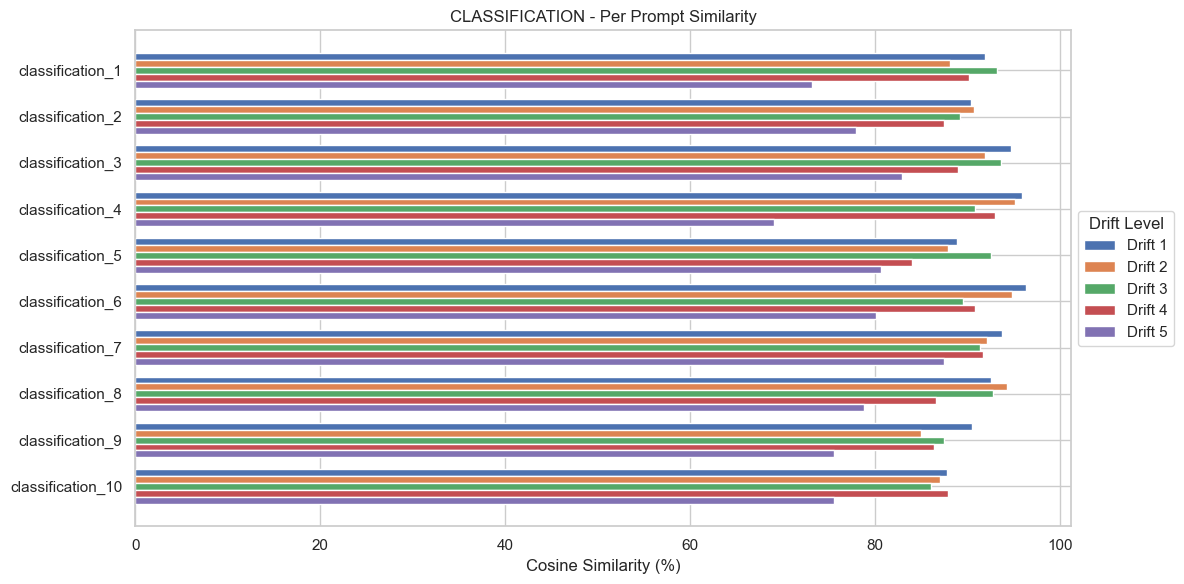

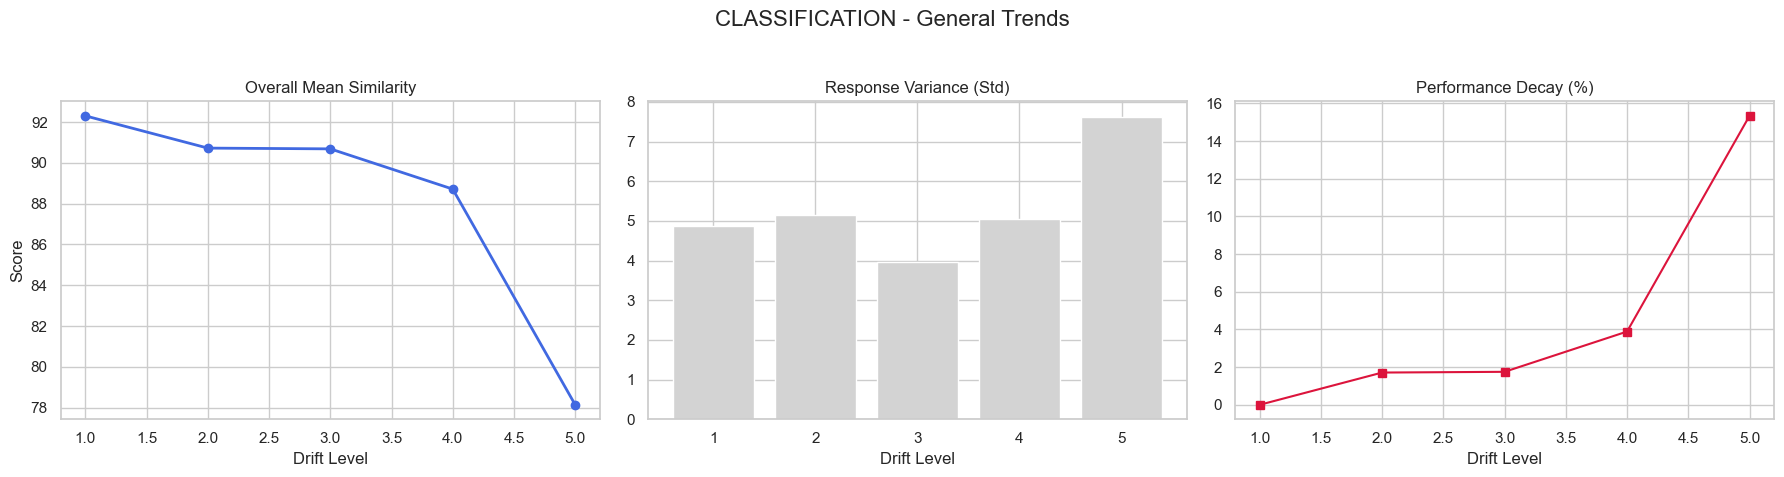

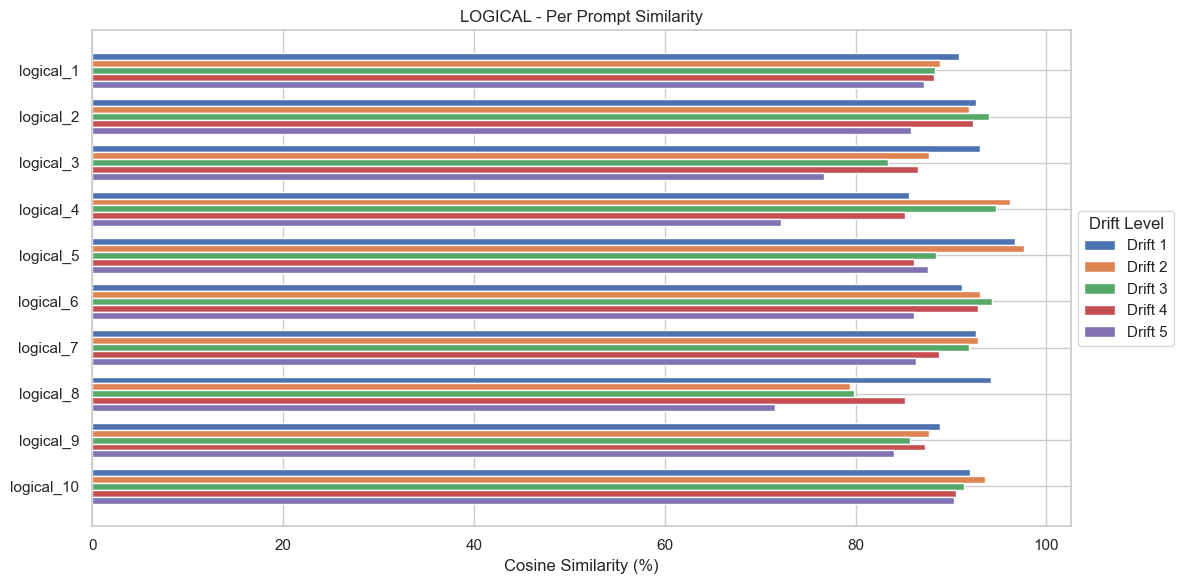

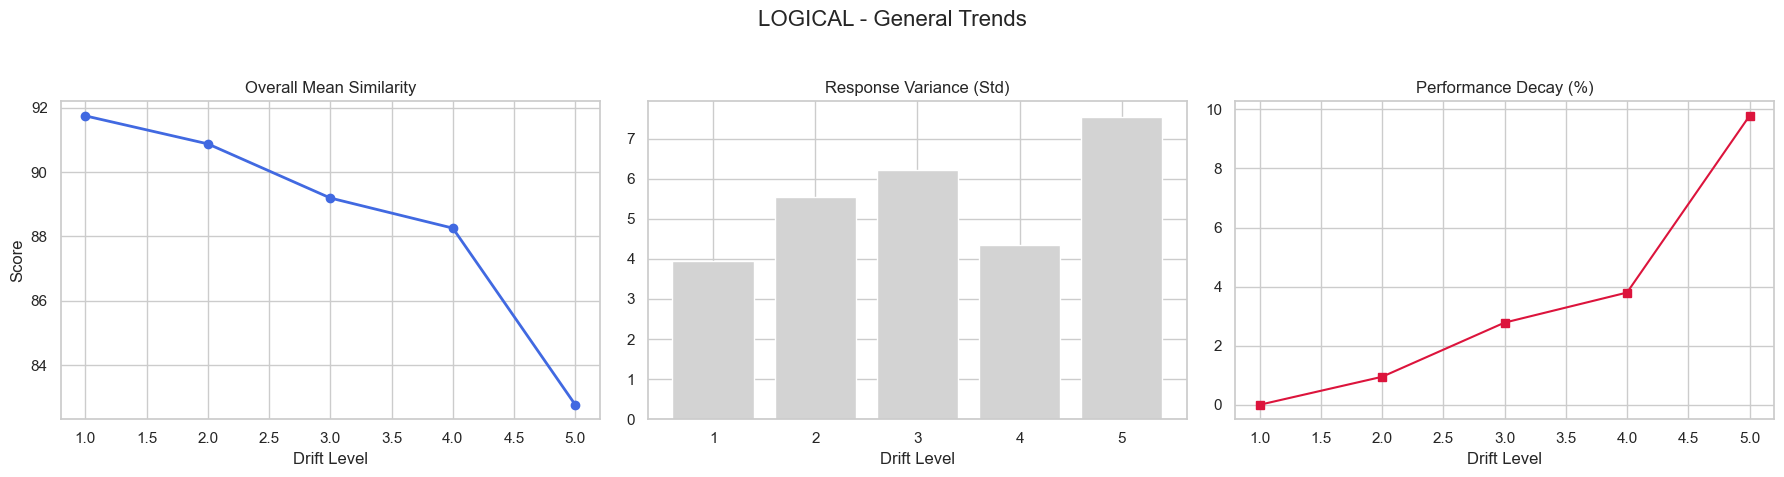

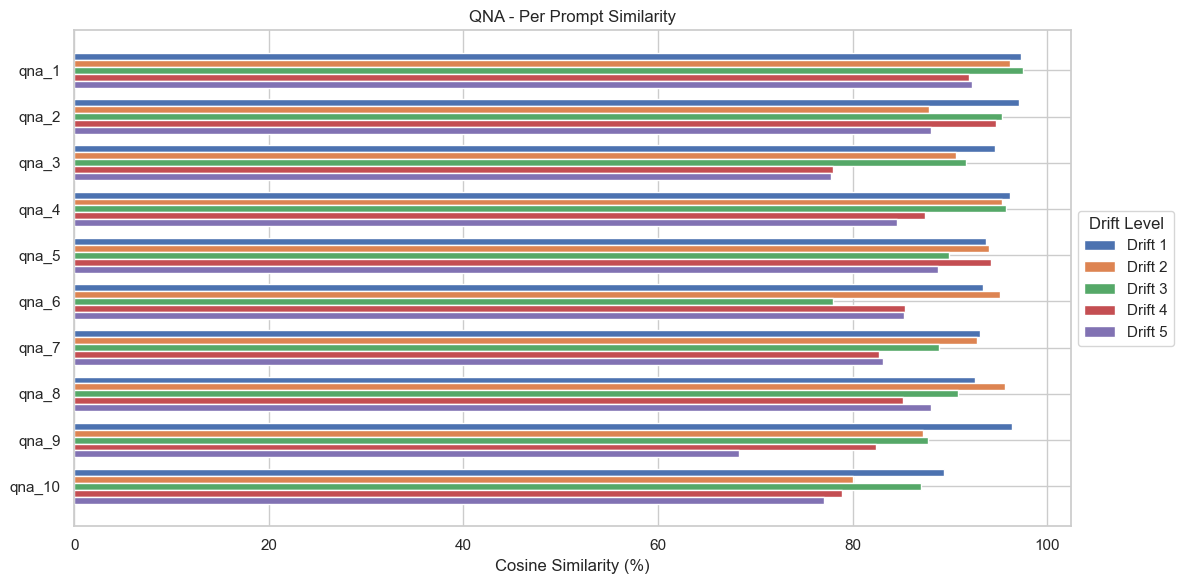

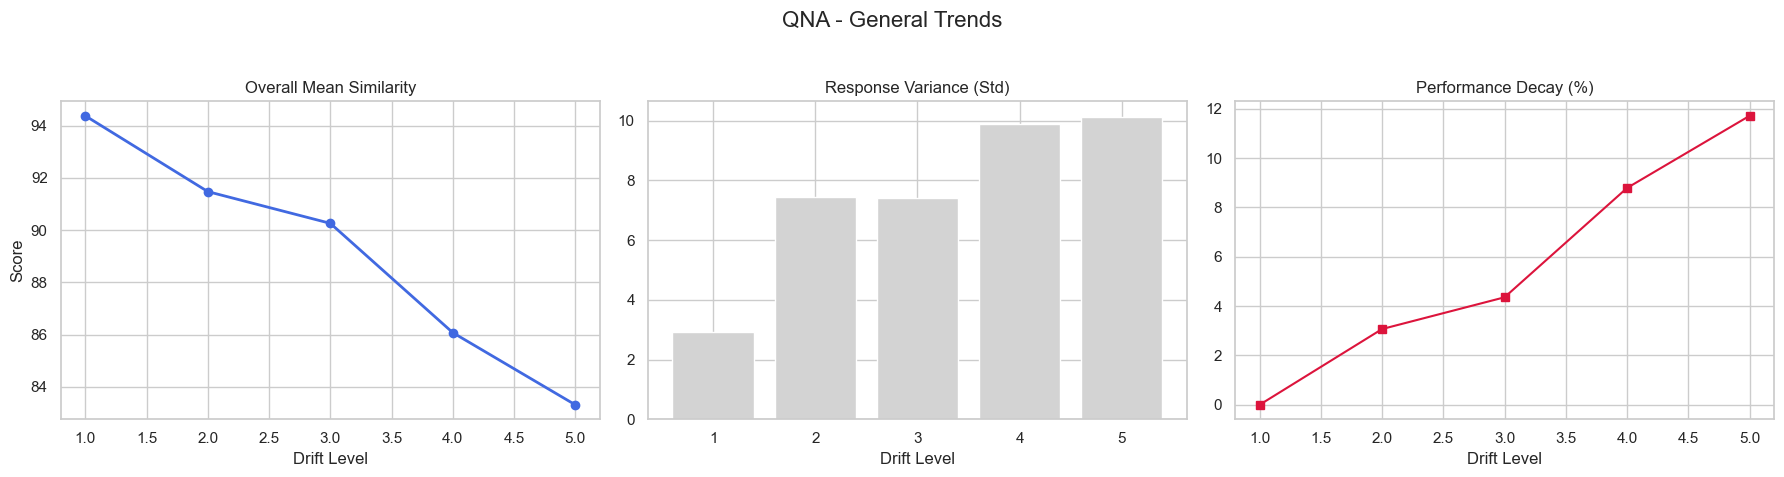

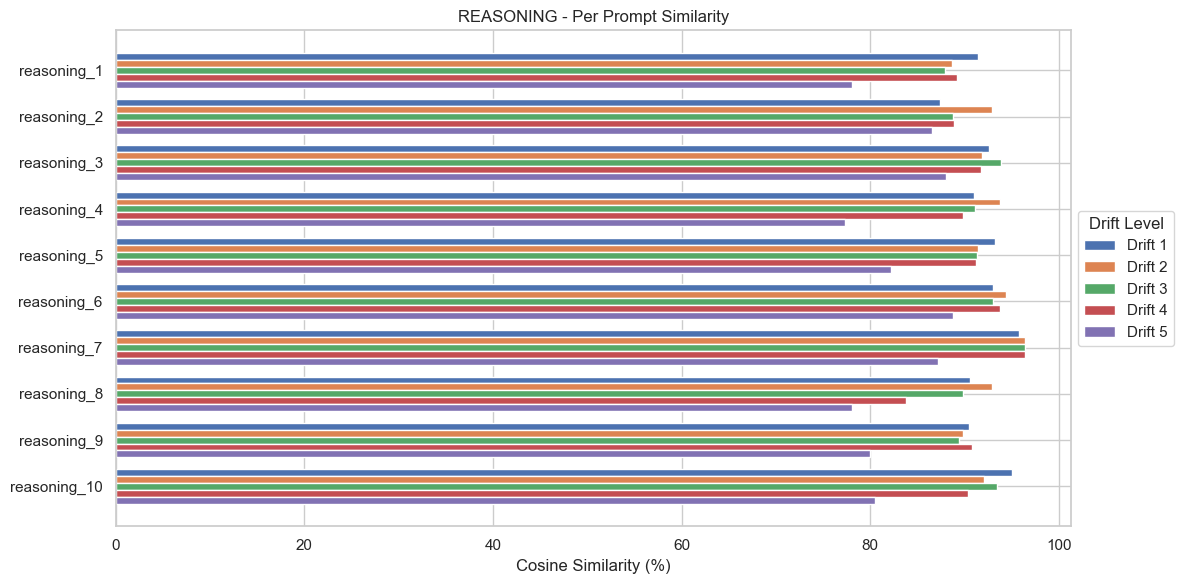

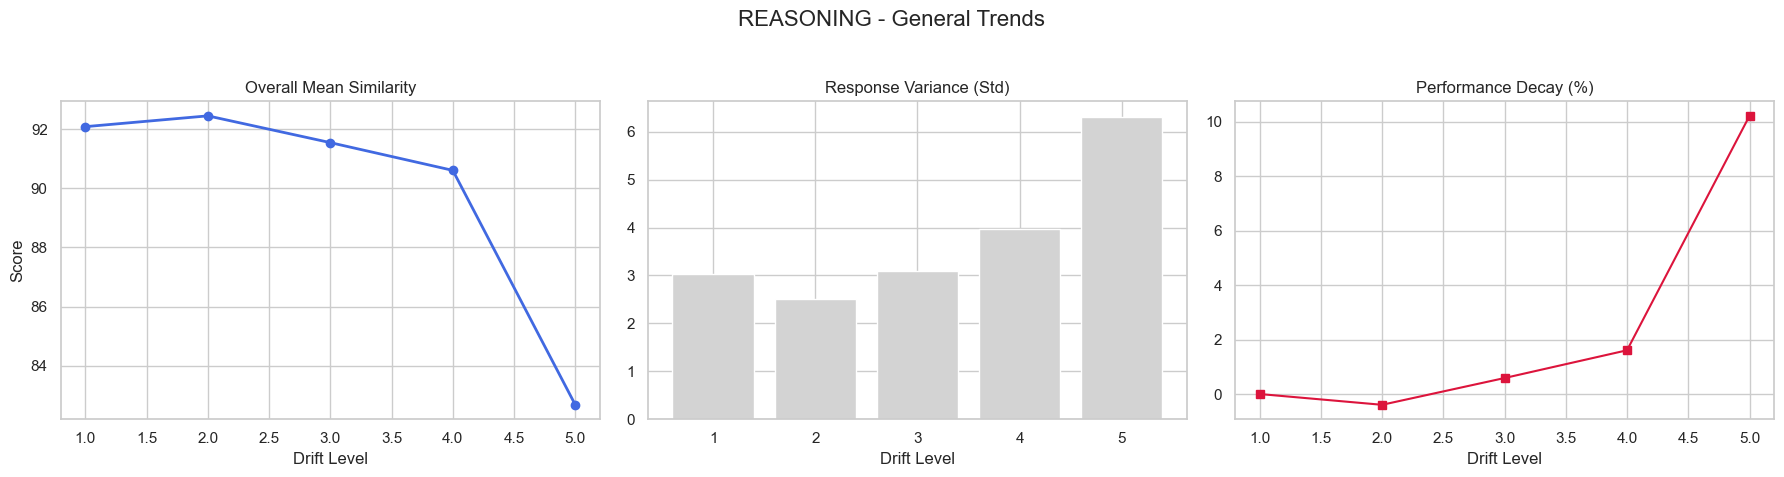


--- Combined Performance Summary Heatmap ---


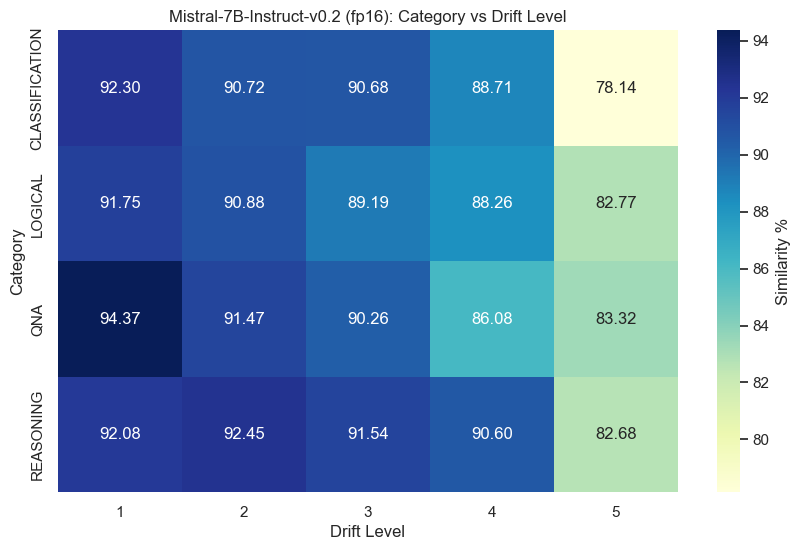

In [7]:
# --- Example Usage ---
show_model_stats("mistralai", "Mistral-7B-Instruct-v0.2", "fp16")

In [8]:
def compare_model_bits(provider, model_name, bits_list):
    """
    Generates a $2 \times 2$ subplot grid comparing quantization bits.
    Each subplot represents a category with lines for each bit type.
    """
    # 1. Data Aggregation
    category_data = {}
    drift_levels = None

    for bit in bits_list:
        target_folder_name = f"{model_name}_{bit}"
        # Ensure INPUT_STATS_BASE is defined globally or passed in
        target_path = os.path.join(INPUT_STATS_BASE, provider, target_folder_name)
        
        if not os.path.exists(target_path):
            print(f"Skipping: {bit} folder not found at {target_path}")
            continue

        stats_files = [f for f in os.listdir(target_path) if f.endswith("_stats.csv")]
        
        for file in stats_files:
            # Extract category name from filename
            category = file.replace("_response_cossim_stats.csv", "").upper()
            df = pd.read_csv(os.path.join(target_path, file))
            
            if drift_levels is None:
                drift_levels = df.iloc[:, 0].values # X-axis values (1-5)
            
            if category not in category_data:
                category_data[category] = {}
            
            # Store values for this specific bit line
            category_data[category][bit] = df["overall_mean"].values

    # 2. Creating the 2x2 Subplot
    categories = list(category_data.keys())
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes_flat = axes.flatten()

    for i in range(4):
        ax = axes_flat[i]
        
        if i < len(categories):
            cat_name = categories[i]
            bits_dict = category_data[cat_name]
            
            # Plot a line for each bit (fp16, int8, int4)
            for bit, values in bits_dict.items():
                ax.plot(drift_levels, values, marker='o', label=bit, linewidth=2.5)
            
            # Subplot Formatting
            ax.set_title(f"Category: {cat_name}", fontsize=14, fontweight='bold')
            ax.set_xlabel("Drift Level", fontsize=10)
            ax.set_ylabel("Cosine Similarity (%)", fontsize=10)
            ax.set_xticks(drift_levels)
            ax.set_ylim(75, 100) # Standardize Y-axis for easier comparison
            ax.grid(True, linestyle='--', alpha=0.4)
            ax.legend(title="Quantization", loc='lower left')
        else:
            # Hide the axis if there are fewer than 4 categories
            ax.axis('off')

    # Global Title and Layout adjustment
    plt.suptitle(f"Quantization Impact Comparison: {model_name}", fontsize=20, y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()



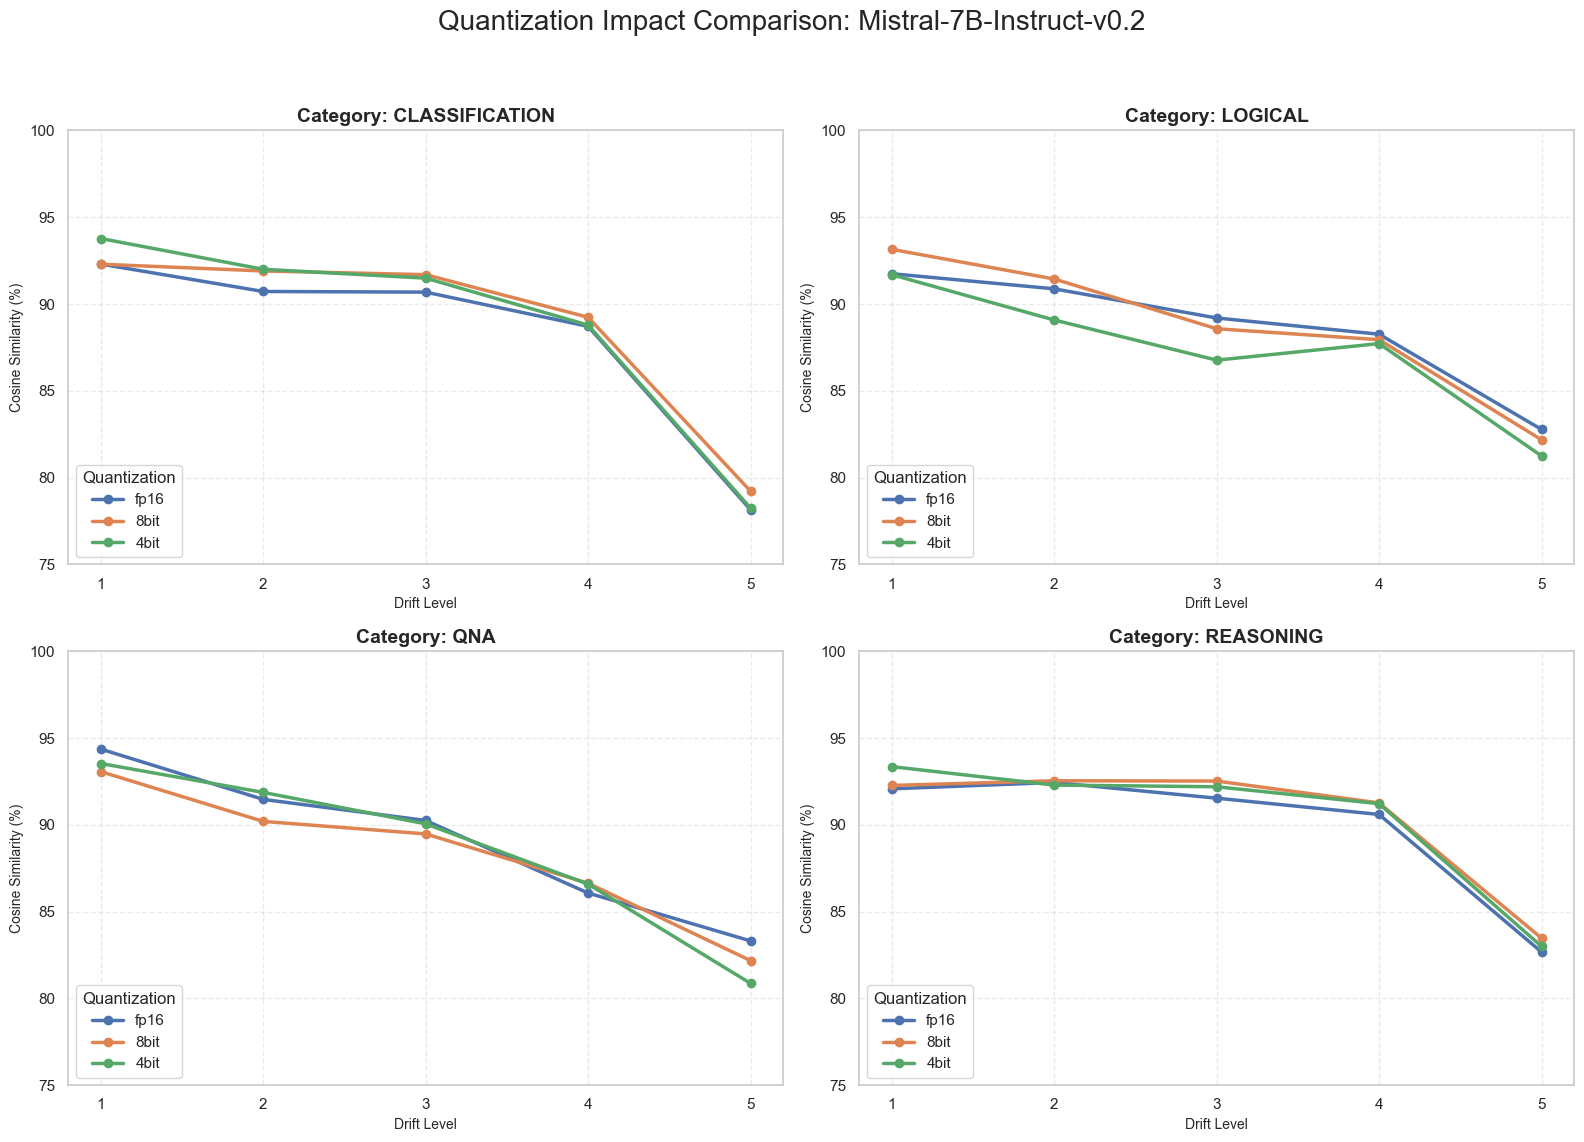

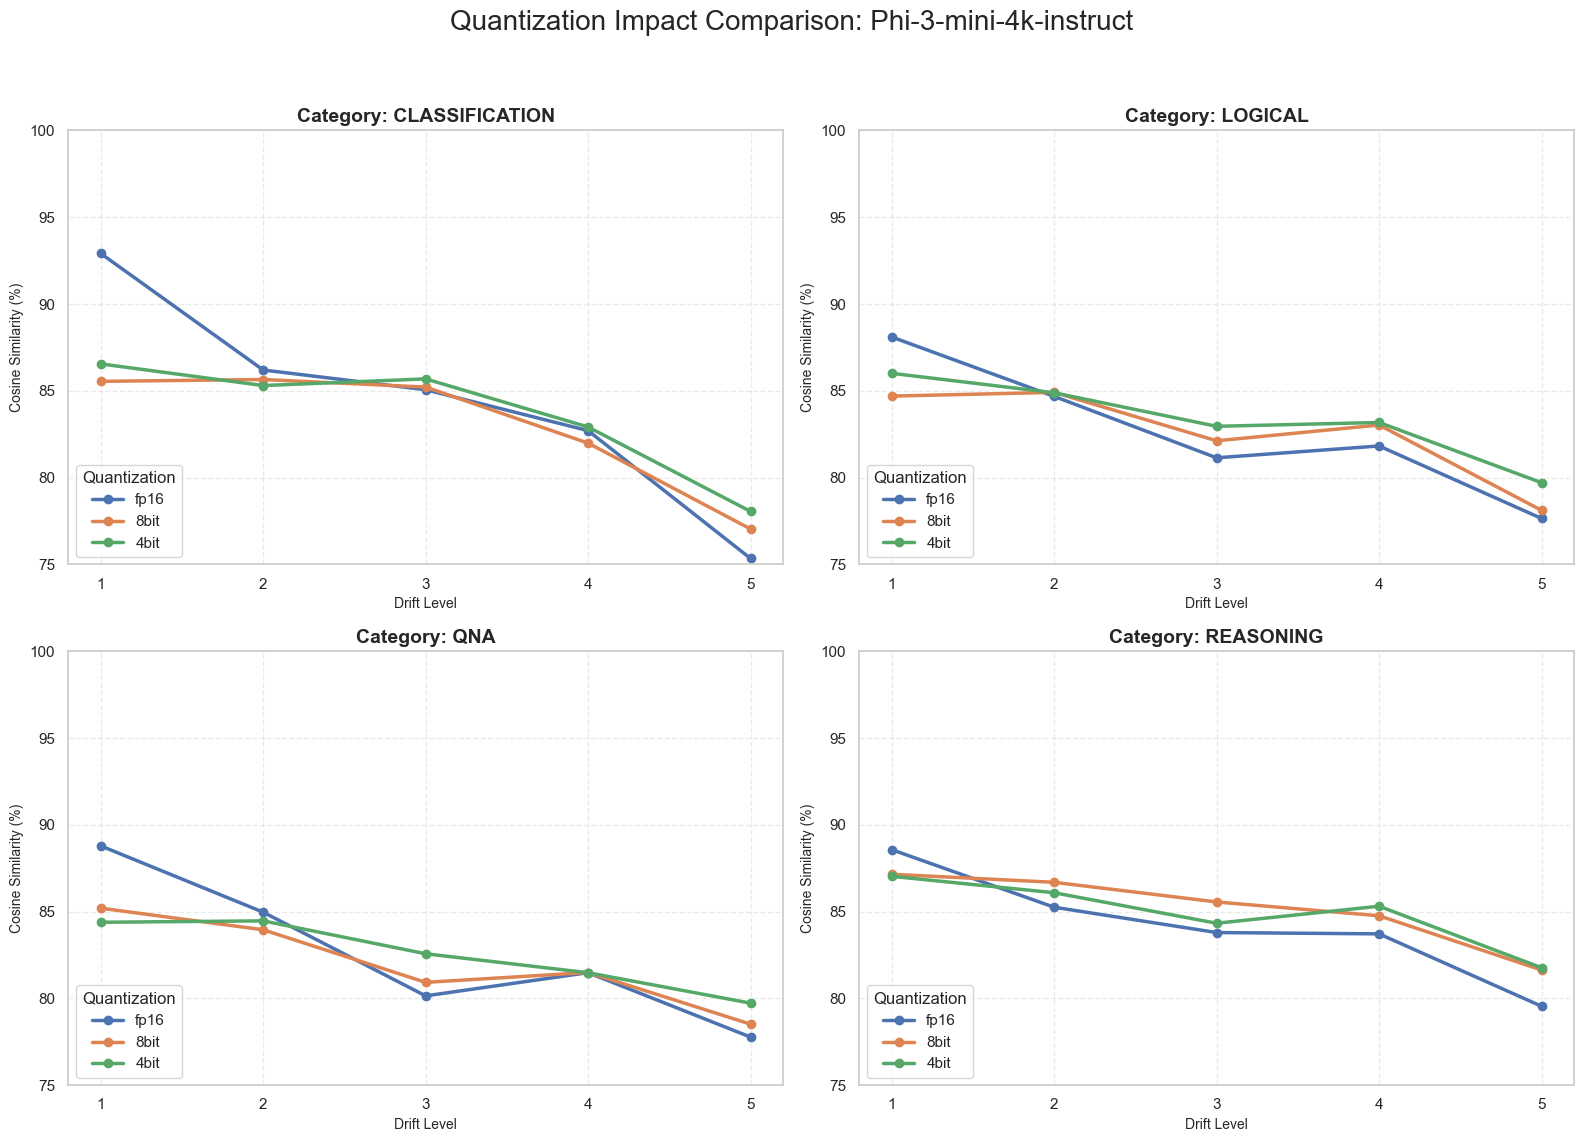

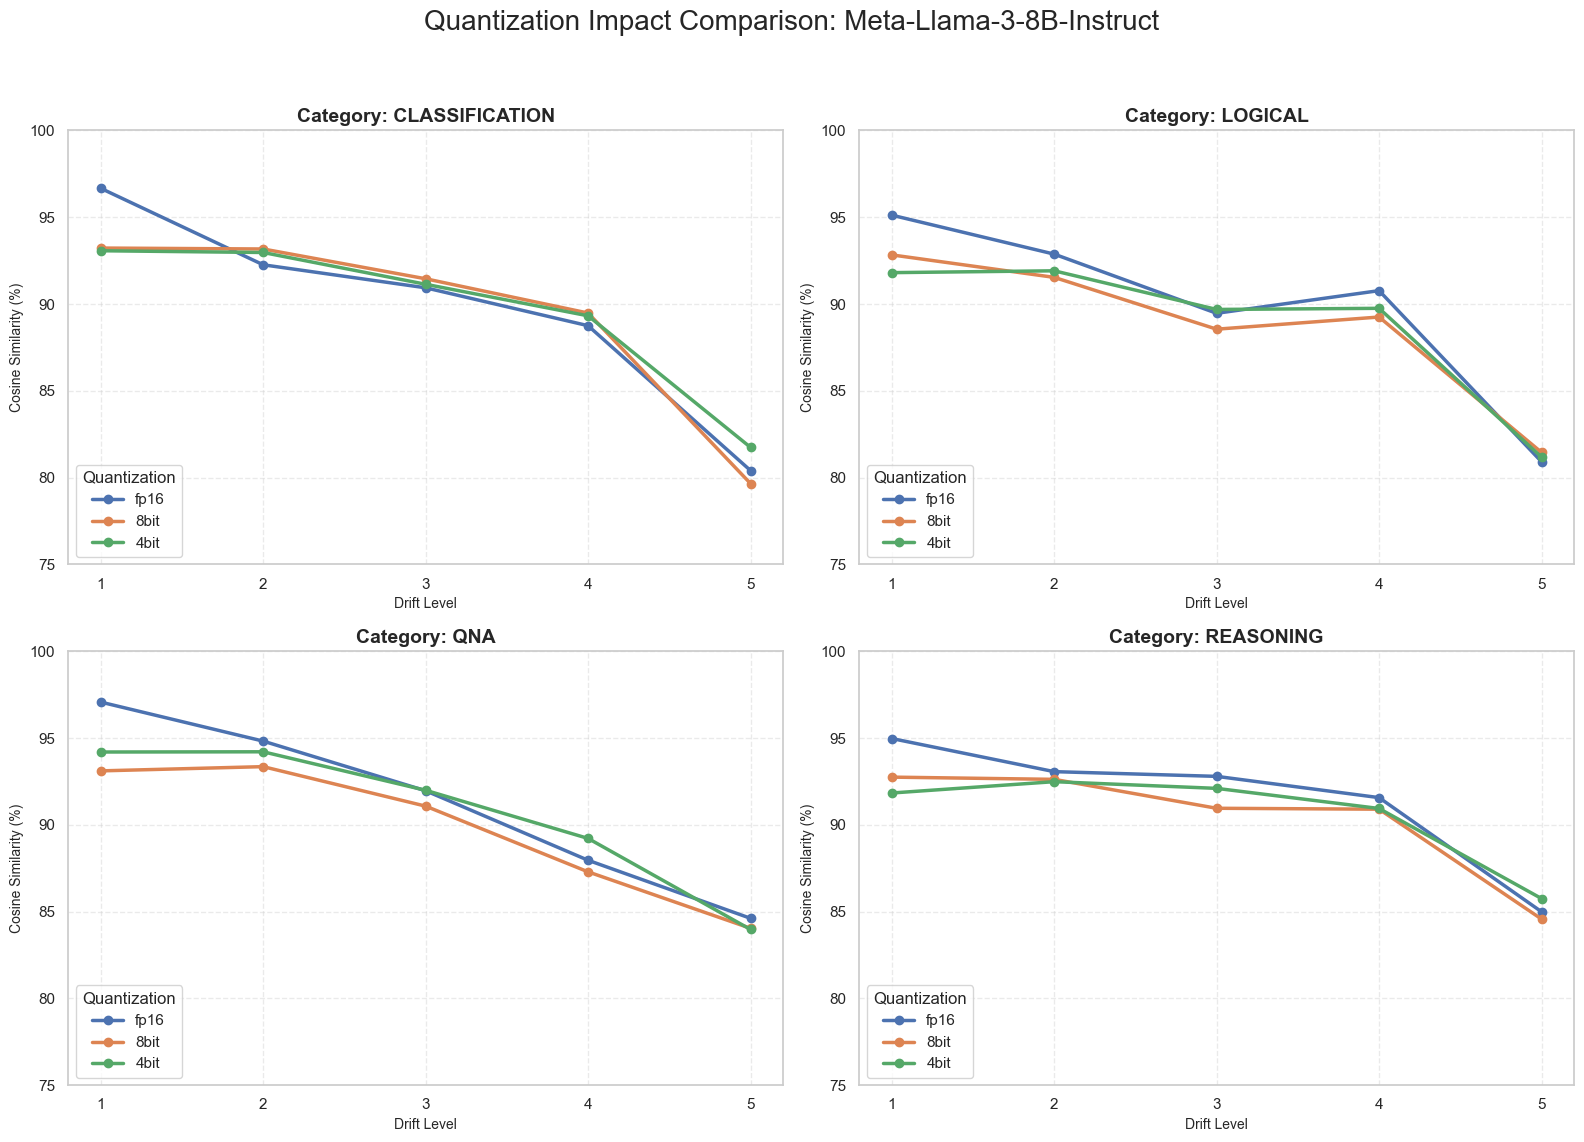

In [9]:
providers = ['mistralai', 'microsoft', 'meta-llama']

for i in providers:
    if i == 'mistralai':
        m = 'Mistral-7B-Instruct-v0.2'
    elif i == 'microsoft':
        m = 'Phi-3-mini-4k-instruct'
    elif i == 'meta-llama':
        m = 'Meta-Llama-3-8B-Instruct'
    compare_model_bits(i, m, ["fp16", "8bit", "4bit"])